<a href="https://colab.research.google.com/github/dewith/reinforcement/blob/main/bandits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bandits

In [1]:
import random

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def environment(true_probabilities: list[float], action: int) -> int:
    """Returns reward 1 or 0."""
    probability = true_probabilities[action]
    return 1 if random.random() < probability else 0


def choose_action(n_actions: int, epsilon: float = 0.1) -> tuple[str, int]:
    """Returns an action."""
    # Explore
    if random.random() < epsilon:
        return "Explore", random.randrange(n_actions)

    # Exploit
    return "Exploit", max(range(n_actions), key=lambda a: values[a])


def update(counts: list[int], values, action: int, reward: int) -> None:
    """Updates counts and values."""
    counts[action] += 1
    n = counts[action]

    # Incremental average
    values[action] += (reward - values[action]) / n


def pprint(lst: list) -> str:
    return "[" + ", ".join([f"{x:.2f}" for x in lst]) + "]"


def plot_progress(history: list[list[float]], true_probabilities: list[float]) -> None:
    """Plot the estimated reward for each action over time."""
    steps = range(1, len(history) + 1)
    palette = sns.color_palette("deep", len(true_probabilities))
    fig, ax = plt.subplots(figsize=(8, 4))

    for action, (true_probability, color) in enumerate(zip(true_probabilities, palette)):
        estimates = [values_at_step[action] for values_at_step in history]
        sns.lineplot(x=steps, y=estimates, color=color, label=f"Action {action}", ax=ax)
        ax.axhline(true_probability, color=color, linestyle="--", alpha=0.45)

    ax.set(
        title=f"Reward estimates after {len(history):,} iterations",
        xlabel="Iteration (dashed lines = true rewards)",
        ylabel="Estimated reward",
        ylim=(0, 1),
    )
    ax.legend(title=None, frameon=False, ncol=len(true_probabilities))
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

Counts: [63, 906, 31]
True rewards: [0.4, 0.65, 0.2]
Estimated rewards: [0.40, 0.65, 0.16]


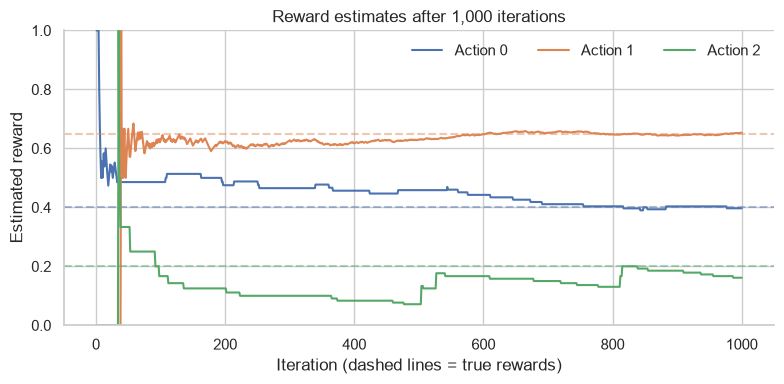

In [3]:
n_actions = 3

true_probabilities = [0.4, 0.65, 0.2]
counts = [0] * n_actions
values = [0.0] * n_actions
estimate_history = []

n_iters = 1000
for step in range(n_iters):
    _, action = choose_action(n_actions, epsilon=0.1)
    reward = environment(true_probabilities, action)
    update(counts, values, action, reward)
    estimate_history.append(values.copy())

print("Counts:", counts)
print("True rewards:", true_probabilities)
print("Estimated rewards:", pprint(values))

plot_progress(estimate_history, true_probabilities)